### 🗂️ Project Summary
This EDA notebook dives into Acme Co.’s 2014–2018 USA sales dataset through:

Data Profiling & Cleaning: Verified schema, handled missing budgets, and corrected data types.

Univariate & Bivariate Analysis: Explored distributions (revenue, margin, unit price), product/channel/region breakdowns, and customer segments.

Trend & Seasonality: Charted monthly and yearly sales patterns, highlighting recurring surges and dips.

Outlier Detection: Identified extreme transactions at both ends of the revenue and unit-price spectra.

Correlation & Segmentation: Assessed relationships between key metrics and clustered customers by revenue vs. profit margin.


### ❓ Problem Statement
Analyze Acme Co.’s 2014–2018 sales data to identify key revenue and profit drivers across products, channels, and regions; uncover seasonal trends and outliers; and align performance against budgets. Use these insights to optimize pricing, promotions, and market expansion for sustainable growth and reduced concentration risk.

### 🎯 Objective
Deliver actionable insights from Acme Co.’s 2014–2018 sales data to:

i)Identify top-performing products, channels, and regions driving revenue and profit

ii)Uncover seasonal trends and anomalies for optimized planning

iii)Spot pricing and margin risks from outlier transactions

iv)Inform pricing, promotion, and market-expansion strategies


v)These findings will guide the design of a Power BI dashboard to support strategic decision-making and sustainable growth.

In [1]:
#importing libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sheets=pd.read_excel('E:/Data Analytics end to end portfolio project/REGIONAL SALES ANALYSIS/Regional Sales Dataset.xlsx',sheet_name=None)


In [3]:
sheets

{'Sales Orders':         OrderNumber  OrderDate  Customer Name Index      Channel  \
 0       SO - 000225 2014-01-01                  126    Wholesale   
 1      SO - 0003378 2014-01-01                   96  Distributor   
 2      SO - 0005126 2014-01-01                    8    Wholesale   
 3      SO - 0005614 2014-01-01                   42       Export   
 4      SO - 0005781 2014-01-01                   73    Wholesale   
 ...             ...        ...                  ...          ...   
 64099  SO - 0007573 2018-02-28                   74    Wholesale   
 64100  SO - 0007706 2018-02-28                   51       Export   
 64101  SO - 0007718 2018-02-28                  136  Distributor   
 64102  SO - 0008084 2018-02-28                  158  Distributor   
 64103  SO - 0008654 2018-02-28                   22  Distributor   
 
       Currency Code Warehouse Code  Delivery Region Index  \
 0               USD         AXW291                    364   
 1               USD         A

In [4]:
# Assign dataframes to each sheet
df_sales=sheets['Sales Orders']
df_customers=sheets['Customers']
df_products=sheets['Products']
df_regions=sheets['Regions']
df_state_rg=sheets['State Regions']
df_budgets=sheets['2017 Budgets']

In [5]:
print(f"df_sales shape is:{df_sales.shape}")
print(f"df_customers shape is:{df_customers.shape}")
print(f"df_products shape is:{df_products.shape}")
print(f"df_regions shape is:{df_regions.shape}")
print(f"df_state_rg shape is:{df_state_rg.shape}")
print(f"df_budgets shape is:{df_budgets.shape}")

df_sales shape is:(64104, 12)
df_customers shape is:(175, 2)
df_products shape is:(30, 2)
df_regions shape is:(994, 15)
df_state_rg shape is:(49, 3)
df_budgets shape is:(30, 2)


In [6]:
df_sales.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270


In [7]:
df_regions.head()

,id,name,county,state_code,state,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,1,Auburn,Lee County,AL,Alabama,City,32.60986,-85.48078,334,62059,21767,38342,152375113,2646161,America/Chicago
1,2,Birmingham,Shelby County/Jefferson County,AL,Alabama,City,33.52744,-86.79905,205,212461,89972,31061,378353942,6591013,America/Chicago
2,3,Decatur,Limestone County/Morgan County,AL,Alabama,City,34.57332,-86.99214,256,55437,22294,41496,141006257,17594716,America/Chicago
3,4,Dothan,Dale County/Houston County/Henry County,AL,Alabama,City,31.23370,-85.40682,334,68567,25913,42426,232166237,835468,America/Chicago
4,5,Hoover,Shelby County/Jefferson County,AL,Alabama,City,33.37695,-86.80558,205,84848,32789,77146,122016784,2553332,America/Chicago


In [8]:
df_customers.head()

,Customer Index,Customer Names
0,1,Geiss Company
1,2,Jaxbean Group
2,3,Ascend Ltd
3,4,Eire Corp
4,5,Blogtags Ltd


In [9]:
df_state_rg.head(5)

,Column1,Column2,Column3
0,State Code,State,Region
1,AL,Alabama,South
2,AR,Arkansas,South
3,AZ,Arizona,West
4,CA,California,West


In [10]:
new_header=df_state_rg.iloc[0]
new_header





Column1    State Code
Column2         State
Column3        Region
Name: 0, dtype: object

In [11]:
df_state_rg.columns=new_header #for making the row in 0 th row as the header or the columns name
df_state_rg.columns

Index(['State Code', 'State', 'Region'], dtype='object', name=0)

In [12]:
df_state_rg.head(5)

,State Code,State,Region
0,State Code,State,Region
1,AL,Alabama,South
2,AR,Arkansas,South
3,AZ,Arizona,West
4,CA,California,West


In [13]:
df_state_rg=df_state_rg[1:].reset_index(drop=True)


In [14]:
df_state_rg.head(5)

,State Code,State,Region
0,AL,Alabama,South
1,AR,Arkansas,South
2,AZ,Arizona,West
3,CA,California,West
4,CO,Colorado,West


In [15]:
df_products.head(5)

,Index,Product Name
0,1,Product 1
1,2,Product 2
2,3,Product 3
3,4,Product 4
4,5,Product 5


In [16]:
df_budgets.head(5)

,Product Name,2017 Budgets
0,Product 1,3016489.209
1,Product 2,3050087.565
2,Product 3,2642352.432
3,Product 4,2885560.824
4,Product 5,3925424.542


In [17]:
#Checking for Null Values
df_sales.isnull().sum()

OrderNumber                  0
OrderDate                    0
Customer Name Index          0
Channel                      0
Currency Code                0
Warehouse Code               0
Delivery Region Index        0
Product Description Index    0
Order Quantity               0
Unit Price                   0
Line Total                   0
Total Unit Cost              0
dtype: int64

In [18]:
df_regions.isnull().sum()

id               0
name             0
county           0
state_code       0
state            0
type             0
latitude         0
longitude        0
area_code        0
population       0
households       0
median_income    0
land_area        0
water_area       0
time_zone        0
dtype: int64

In [19]:
df_state_rg.isnull().sum()

0
State Code    0
State         0
Region        0
dtype: int64

In [20]:
df_budgets.isnull().sum()


Product Name    0
2017 Budgets    0
dtype: int64

### Data Cleaning and Wrangling

In [21]:
#join noperation between sales and customers sheet(Merge with customers)
df=df_sales.merge(
    df_customers,
    how='left',
    left_on='Customer Name Index',
    right_on='Customer Index'
)

In [22]:
df

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost,Customer Index,Customer Names
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343,126,Rhynoodle Ltd
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918,96,Thoughtmix Ltd
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740,8,Amerisourc Corp
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852,42,Colgate-Pa Group
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270,73,Deseret Group
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64099,SO - 0007573,2018-02-28,74,Wholesale,USD,AXW291,825,26,12,1815.7,21788.4,980.478,74,Dazzlesphe Corp
64100,SO - 0007706,2018-02-28,51,Export,USD,NXH382,444,21,6,864.3,5185.8,579.081,51,Yombu Corp
64101,SO - 0007718,2018-02-28,136,Distributor,USD,AXW291,312,13,11,3953.0,43483.0,2648.510,136,Bath Group
64102,SO - 0008084,2018-02-28,158,Distributor,USD,AXW291,737,20,7,3959.7,27717.9,2930.178,158,Linklinks Ltd


In [23]:
# Merge with products
df=df.merge(
    df_products,
    how='left',
    left_on='Product Description Index',
    right_on='Index'
)

In [24]:
df

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost,Customer Index,Customer Names,Index,Product Name
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343,126,Rhynoodle Ltd,27,Product 27
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918,96,Thoughtmix Ltd,20,Product 20
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740,8,Amerisourc Corp,26,Product 26
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852,42,Colgate-Pa Group,7,Product 7
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270,73,Deseret Group,8,Product 8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64099,SO - 0007573,2018-02-28,74,Wholesale,USD,AXW291,825,26,12,1815.7,21788.4,980.478,74,Dazzlesphe Corp,26,Product 26
64100,SO - 0007706,2018-02-28,51,Export,USD,NXH382,444,21,6,864.3,5185.8,579.081,51,Yombu Corp,21,Product 21
64101,SO - 0007718,2018-02-28,136,Distributor,USD,AXW291,312,13,11,3953.0,43483.0,2648.510,136,Bath Group,13,Product 13
64102,SO - 0008084,2018-02-28,158,Distributor,USD,AXW291,737,20,7,3959.7,27717.9,2930.178,158,Linklinks Ltd,20,Product 20


In [25]:
# Merge with regions
df=df.merge(
    df_regions,
    how='left',
    left_on='Delivery Region Index',
    right_on='id'
)

In [26]:
df.columns

Index(['OrderNumber', 'OrderDate', 'Customer Name Index', 'Channel',
       'Currency Code', 'Warehouse Code', 'Delivery Region Index',
       'Product Description Index', 'Order Quantity', 'Unit Price',
       'Line Total', 'Total Unit Cost', 'Customer Index', 'Customer Names',
       'Index', 'Product Name', 'id', 'name', 'county', 'state_code', 'state',
       'type', 'latitude', 'longitude', 'area_code', 'population',
       'households', 'median_income', 'land_area', 'water_area', 'time_zone'],
      dtype='object')

In [27]:
# Merge with state regions
df=df.merge(
    df_state_rg[['State Code','Region']],  # as we already have the state name column in df no need another time 
    how='left',
    left_on='state_code',
    right_on='State Code'
)

In [28]:
df

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,State Code,Region
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,GA,South
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,IN,Midwest
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles,CA,West
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,IN,Midwest
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,-72.52443,959,58007,24141,63158,70972793,720300,America/New York,CT,Northeast
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64099,SO - 0007573,2018-02-28,74,Wholesale,USD,AXW291,825,26,12,1815.7,...,-74.82877,445,51326,18095,69878,26311722,253129,America/New York,PA,Northeast
64100,SO - 0007706,2018-02-28,51,Export,USD,NXH382,444,21,6,864.3,...,-88.03424,847,69308,26242,71573,35271964,370235,America/Chicago,IL,Midwest
64101,SO - 0007718,2018-02-28,136,Distributor,USD,AXW291,312,13,11,3953.0,...,-80.20644,954,57234,20651,42786,22943340,594611,America/New York,FL,South
64102,SO - 0008084,2018-02-28,158,Distributor,USD,AXW291,737,20,7,3959.7,...,-78.74182,716,87514,38912,48662,76228647,162756,America/New York,NY,Northeast


In [29]:
df.columns

Index(['OrderNumber', 'OrderDate', 'Customer Name Index', 'Channel',
       'Currency Code', 'Warehouse Code', 'Delivery Region Index',
       'Product Description Index', 'Order Quantity', 'Unit Price',
       'Line Total', 'Total Unit Cost', 'Customer Index', 'Customer Names',
       'Index', 'Product Name', 'id', 'name', 'county', 'state_code', 'state',
       'type', 'latitude', 'longitude', 'area_code', 'population',
       'households', 'median_income', 'land_area', 'water_area', 'time_zone',
       'State Code', 'Region'],
      dtype='object')

In [30]:
# Merge with budgets
df=df.merge(
    df_budgets,   
    how='left',
    on='Product Name'
)

In [31]:
df

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,area_code,population,households,median_income,land_area,water_area,time_zone,State Code,Region,2017 Budgets
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,912,145674,52798,36466,268318796,13908113,America/New York,GA,South,964940.231
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,IN,Midwest,2067108.120
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,925,79510,26020,124759,62489257,386195,America/Los Angeles,CA,West,5685138.270
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,IN,Midwest,889737.555
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,959,58007,24141,63158,70972793,720300,America/New York,CT,Northeast,1085037.329
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64099,SO - 0007573,2018-02-28,74,Wholesale,USD,AXW291,825,26,12,1815.7,...,445,51326,18095,69878,26311722,253129,America/New York,PA,Northeast,5685138.270
64100,SO - 0007706,2018-02-28,51,Export,USD,NXH382,444,21,6,864.3,...,847,69308,26242,71573,35271964,370235,America/Chicago,IL,Midwest,959899.218
64101,SO - 0007718,2018-02-28,136,Distributor,USD,AXW291,312,13,11,3953.0,...,954,57234,20651,42786,22943340,594611,America/New York,FL,South,3720639.645
64102,SO - 0008084,2018-02-28,158,Distributor,USD,AXW291,737,20,7,3959.7,...,716,87514,38912,48662,76228647,162756,America/New York,NY,Northeast,2067108.120


In [32]:
df.to_csv('file.csv')

#### The above csv file is acted as a temporary csv file which contains some duplicate columns created during join operation we have to deal with it using MS Excel



In [33]:
df

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,area_code,population,households,median_income,land_area,water_area,time_zone,State Code,Region,2017 Budgets
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,912,145674,52798,36466,268318796,13908113,America/New York,GA,South,964940.231
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,IN,Midwest,2067108.120
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,925,79510,26020,124759,62489257,386195,America/Los Angeles,CA,West,5685138.270
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,IN,Midwest,889737.555
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,959,58007,24141,63158,70972793,720300,America/New York,CT,Northeast,1085037.329
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64099,SO - 0007573,2018-02-28,74,Wholesale,USD,AXW291,825,26,12,1815.7,...,445,51326,18095,69878,26311722,253129,America/New York,PA,Northeast,5685138.270
64100,SO - 0007706,2018-02-28,51,Export,USD,NXH382,444,21,6,864.3,...,847,69308,26242,71573,35271964,370235,America/Chicago,IL,Midwest,959899.218
64101,SO - 0007718,2018-02-28,136,Distributor,USD,AXW291,312,13,11,3953.0,...,954,57234,20651,42786,22943340,594611,America/New York,FL,South,3720639.645
64102,SO - 0008084,2018-02-28,158,Distributor,USD,AXW291,737,20,7,3959.7,...,716,87514,38912,48662,76228647,162756,America/New York,NY,Northeast,2067108.120


In [34]:
cols_to_drop = [
    'Customer Index', 'Index', 'id', 'State Code',
    # add any auto-generated cols you don't need
]

In [35]:
df=df.drop(columns=cols_to_drop,errors='ignore')

In [36]:
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,Region,2017 Budgets
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,South,964940.231
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,Midwest,2067108.120
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles,West,5685138.270
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,Midwest,889737.555
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,-72.52443,959,58007,24141,63158,70972793,720300,America/New York,Northeast,1085037.329


In [37]:
#convert all cols to lowercase for consistency and easier access
df.columns=df.columns.str.lower()
df.columns.values

array(['ordernumber', 'orderdate', 'customer name index', 'channel',
       'currency code', 'warehouse code', 'delivery region index',
       'product description index', 'order quantity', 'unit price',
       'line total', 'total unit cost', 'customer names', 'product name',
       'name', 'county', 'state_code', 'state', 'type', 'latitude',
       'longitude', 'area_code', 'population', 'households',
       'median_income', 'land_area', 'water_area', 'time_zone', 'region',
       '2017 budgets'], dtype=object)

In [38]:
#keep the imp cols and delete the columns which are not required for analysis
cols_to_keep = [
    'ordernumber',        # unique order ID
    'orderdate',          # date when the order was placed
    'customer names',     # customer who placed the order
    'channel',            # sales channel (e.g., Wholesale, Distributor)
    'product name',       # product purchased
    'order quantity',     # number of units ordered
    'unit price',         # price per unit
    'line total',         # revenue for this line item (qty × unit_price)
    'total unit cost',    # company’s cost for this line item
    'state_code',         # two-letter state code
    'state',              # full state name
    'region',             # broader U.S. region (e.g., South, West)
    'latitude',           # latitude of delivery city(needed for dashboard making)
    'longitude',          # longitude of delivery city(needed for dashboard making)
    '2017 budgets'        # budget target for this product in 2017
]

In [39]:
df=df[cols_to_keep]

In [40]:
df.head()

,ordernumber,orderdate,customer names,channel,product name,order quantity,unit price,line total,total unit cost,state_code,state,region,latitude,longitude,2017 budgets
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Georgia,South,32.08354,-81.09983,964940.231
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Indiana,Midwest,39.61366,-86.10665,2067108.120
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,California,West,37.66243,-121.87468,5685138.270
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Indiana,Midwest,39.16533,-86.52639,889737.555
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Connecticut,Northeast,41.77524,-72.52443,1085037.329


In [41]:
#Rename to more Pythonic / self-explanatory names, including region
df = df.rename(columns={
    'ordernumber'      : 'order_number',   # snake_case for consistency
    'orderdate'        : 'order_date',     # date of the order
    'customer names'   : 'customer_name',  # customer who placed it
    'product name'     : 'product_name',   # product sold
    'order quantity'   : 'quantity',       # units sold
    'unit price'       : 'unit_price',     # price per unit in USD
    'line total'       : 'revenue',        # revenue for the line item(nothing but its revenue)
    'total unit cost'  : 'cost',           # cost for the line item
    'state_code'       : 'state',          # two-letter state code
    'state'            : 'state_name',     # full state name
    'region'           : 'us_region',      # broader U.S. region
    'latitude'         : 'lat',            # latitude (float)
    'longitude'        : 'lon',            # longitude (float)
    '2017 budgets'     : 'budget'          # 2017 budget target (float)
})

In [42]:
df.head()

,order_number,order_date,customer_name,channel,product_name,quantity,unit_price,revenue,cost,state,state_name,us_region,lat,lon,budget
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Georgia,South,32.08354,-81.09983,964940.231
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Indiana,Midwest,39.61366,-86.10665,2067108.120
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,California,West,37.66243,-121.87468,5685138.270
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Indiana,Midwest,39.16533,-86.52639,889737.555
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Connecticut,Northeast,41.77524,-72.52443,1085037.329


In [43]:
# Blank out budgets for non-2017 orders i.e for the orders of 2014,2015,2016,2018 we have to fill null values in the budget column
df.loc[df['order_date'].dt.year != 2017,'budget']=pd.NA
df[['order_date','product_name','revenue','budget']].head(10)

,order_date,product_name,revenue,budget
0,2014-01-01,Product 27,14994.6,NaN
1,2014-01-01,Product 20,25868.7,NaN
2,2014-01-01,Product 26,5869.2,NaN
3,2014-01-01,Product 7,16368.1,NaN
4,2014-01-01,Product 8,18331.2,NaN
5,2014-01-01,Product 23,57412.3,NaN
6,2014-01-01,Product 1,20120.1,NaN
7,2014-01-01,Product 25,10452.0,NaN
8,2014-01-01,Product 13,19262.5,NaN
9,2014-01-01,Product 14,34974.0,NaN


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_number   64104 non-null  object        
 1   order_date     64104 non-null  datetime64[ns]
 2   customer_name  64104 non-null  object        
 3   channel        64104 non-null  object        
 4   product_name   64104 non-null  object        
 5   quantity       64104 non-null  int64         
 6   unit_price     64104 non-null  float64       
 7   revenue        64104 non-null  float64       
 8   cost           64104 non-null  float64       
 9   state          64104 non-null  object        
 10  state_name     64104 non-null  object        
 11  us_region      64104 non-null  object        
 12  lat            64104 non-null  float64       
 13  lon            64104 non-null  float64       
 14  budget         15263 non-null  float64       
dtypes: datetime64[ns](1

In [45]:
# Check for missing values in each column of the dataset
df.isnull().sum()

order_number         0
order_date           0
customer_name        0
channel              0
product_name         0
quantity             0
unit_price           0
revenue              0
cost                 0
state                0
state_name           0
us_region            0
lat                  0
lon                  0
budget           48841
dtype: int64

In [46]:
df_2017=df[df['order_date'].dt.year==2017]

In [47]:
df_2017.head(5)

,order_number,order_date,customer_name,channel,product_name,quantity,unit_price,revenue,cost,state,state_name,us_region,lat,lon,budget
46363,SO - 0002544,2017-01-01,NCS Group,Wholesale,Product 30,6,1239.5,7437.0,1028.785,NJ,New Jersey,Northeast,40.77955,-74.02375,1011609.684
46364,SO - 0006431,2017-01-01,Epic Group,Wholesale,Product 13,5,1829.1,9145.5,1207.206,CO,Colorado,West,39.06387,-108.55065,3720639.645
46365,SO - 0007491,2017-01-01,State Ltd,Wholesale,Product 15,9,2412.0,21708.0,1664.280,CA,California,West,33.96168,-118.35313,3299478.315
46366,SO - 0008741,2017-01-01,Fivebridge Ltd,Wholesale,Product 8,8,904.5,7236.0,750.735,IA,Iowa,Midwest,42.50056,-90.66457,1085037.329
46367,SO - 0009295,2017-01-01,Tagfeed Ltd,Wholesale,Product 2,12,1112.2,13346.4,811.906,FL,Florida,South,28.47689,-82.52546,3050087.565


### 🛠 Feature Engineering

In [48]:
# calculate the total cost for each line item
df['total_cost']=df['quantity']*df['cost']
#Calculate profit as revenue minus total_cost
df['profit']=df['revenue']-df['total_cost']
#Calculate profit margin as a percentage
df['profit_margin_pct']=df['profit']/df['revenue']*100
#Extract full month name from order_date for labeling (e.g., 'January', 'February')
df['order_month_name']=df['order_date'].dt.month_name()
#Extract month number from order_date for correct sorting (1–12)
df['order_month_num']=df['order_date'].dt.month

In [49]:
df

,order_number,order_date,customer_name,channel,product_name,quantity,unit_price,revenue,cost,state,state_name,us_region,lat,lon,budget,total_cost,profit,profit_margin_pct,order_month_name,order_month_num
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Georgia,South,32.08354,-81.09983,NaN,10946.058,4048.542,27.0,January,1
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Indiana,Midwest,39.61366,-86.10665,NaN,13969.098,11899.602,46.0,January,1
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,California,West,37.66243,-121.87468,NaN,4108.440,1760.760,30.0,January,1
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Indiana,Midwest,39.16533,-86.52639,NaN,7201.964,9166.136,56.0,January,1
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Connecticut,Northeast,41.77524,-72.52443,NaN,10082.160,8249.040,45.0,January,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64099,SO - 0007573,2018-02-28,Dazzlesphe Corp,Wholesale,Product 26,12,1815.7,21788.4,980.478,PA,Pennsylvania,Northeast,40.15511,-74.82877,NaN,11765.736,10022.664,46.0,February,2
64100,SO - 0007706,2018-02-28,Yombu Corp,Export,Product 21,6,864.3,5185.8,579.081,IL,Illinois,Midwest,42.11030,-88.03424,NaN,3474.486,1711.314,33.0,February,2
64101,SO - 0007718,2018-02-28,Bath Group,Distributor,Product 13,11,3953.0,43483.0,2648.510,FL,Florida,South,26.24453,-80.20644,NaN,29133.610,14349.390,33.0,February,2
64102,SO - 0008084,2018-02-28,Linklinks Ltd,Distributor,Product 20,7,3959.7,27717.9,2930.178,NY,New York,Northeast,42.91002,-78.74182,NaN,20511.246,7206.654,26.0,February,2


### 📊 Exploratory Analysis

#### 🔹 1. Monthly Sales Trend Over Time
Goal: Track revenue trends over time to detect seasonality or sales spikes

Chart:Line Chart

Structure: Line with markers to highlight monthly revenue points clearly

In [50]:
# Convert order_date to monthly period (e.g., 2022-01, 2022-02)
df['order_month']=df['order_date'].dt.to_period('M')
df['order_month']

0        2014-01
1        2014-01
2        2014-01
3        2014-01
4        2014-01
          ...   
64099    2018-02
64100    2018-02
64101    2018-02
64102    2018-02
64103    2018-02
Name: order_month, Length: 64104, dtype: period[M]

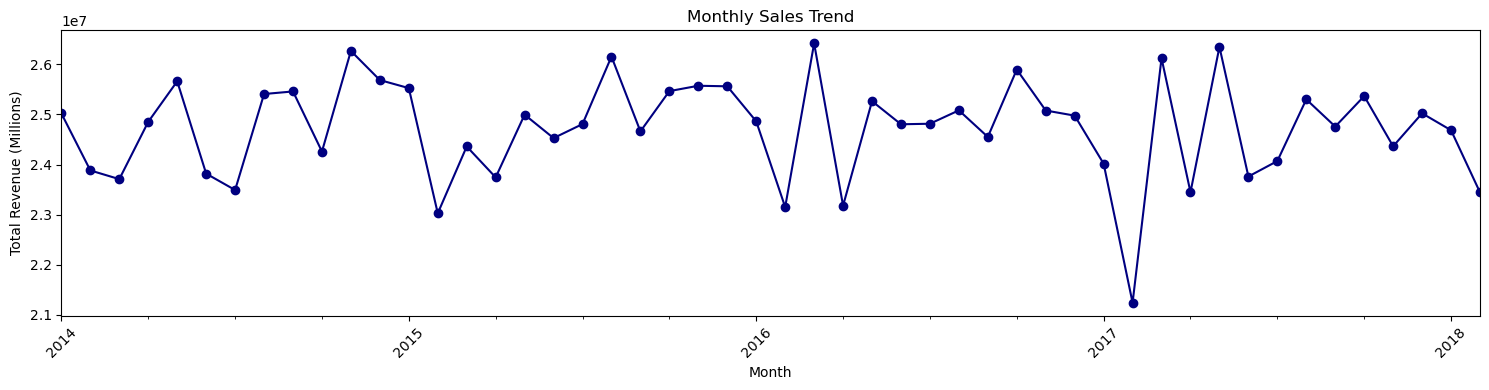

In [51]:
# Calculate total revenue for each month
monthly_sales=df.groupby('order_month')['revenue'].sum()
plt.figure(figsize=(15,4))
monthly_sales.plot(marker='o',color='navy')
# Add title and axis labels
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue (Millions)')
# Rotate x-axis labels for better readability
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Insights ---
#### Sales consistently cycle between 24M & 26 M, with clear peaks in late spring to early summer (May–June) and troughs each January.

### 🔹 2. Monthly Sales Trend (All Years Combined)

In [52]:
# 1. Filter out any 2018 orders
df_=df[df['order_date'].dt.year!=2018] # exclude any partial-year data (i.e., January and February of 2018) so that the monthly totals aren’t skewed by an incomplete year.
                                            #I create df_ so I don’t alter the original df, preserving it intact for other analyses while filtering just for this chart.
# 2. Group by month number and month name, sum revenue, then sort by month number
monthly_sales= (
    df.groupby(['order_month_num','order_month_name'])['revenue'].sum().sort_index()
) 
monthly_sales                                          
                                            

order_month_num  order_month_name
1                January             124111403.0
2                February            114747751.0
3                March               100613652.1
4                April                95224755.0
5                May                 102272116.5
6                June                 96912692.7
7                July                 97185201.8
8                August              101947025.8
9                September            99432301.4
10               October             100988872.2
11               November            101285199.8
12               December            101247927.7
Name: revenue, dtype: float64

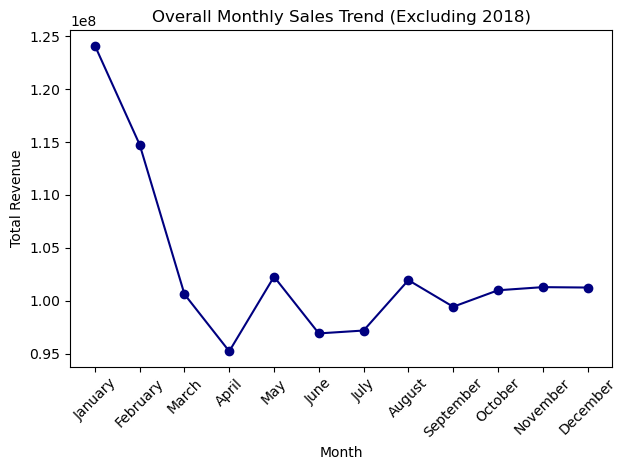

In [53]:
plt.Figure(figsize=(13,4))
plt.plot(
    monthly_sales.index.get_level_values(1), # X-axis: month names
    monthly_sales.values,# Y-axis: total revenue
    marker='o',
    color='navy'
)
plt.title('Overall Monthly Sales Trend (Excluding 2018)')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insights ---
- The revenue shows a 22% decline from a peak of 1.25 in January to 0.97 by December, indicating a potential market or operational challenge.
- A notable dip occurs from April to June (~1.10 to 0.95), followed by a slight recovery in August (~1.05), suggesting seasonal influences or regional variations.
- The lack of a Q4 spike (e.g., December at 0.97) may indicate missed holiday sales opportunities or a need to analyze channel performance.

### 🔹 3. Top 10 Products by Revenue (in Millions)
Goal: Identify the highest-grossing products to focus marketing and inventory efforts

Chart: Horizontal bar chart

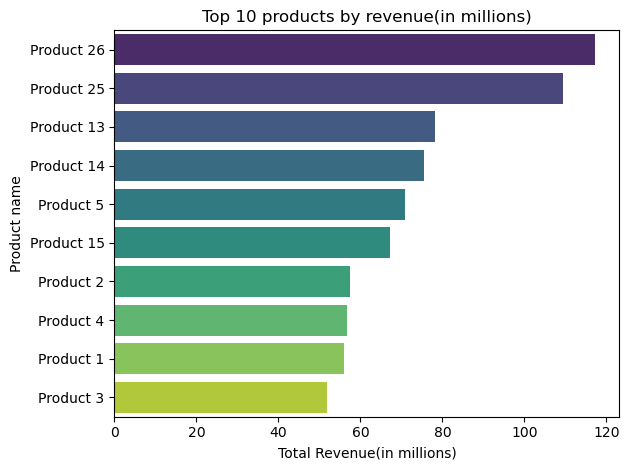

In [54]:
import warnings
warnings.filterwarnings('ignore')
# Calculate total revenue for each product and convert values to millions
top_prod=df.groupby('product_name')['revenue'].sum()/1_000_000
top_prod=top_prod.nlargest(10)
plt.Figure(figsize=(9,4))
# Plot a horizontal bar chart: x-axis as revenue in millions, y-axis as product names
sns.barplot(
    x=top_prod.values,
    y=top_prod.index,
    palette='viridis'
)
# Add title and axis labels
plt.title('Top 10 products by revenue(in millions)')
plt.xlabel('Total Revenue(in millions)')
plt.ylabel('Product name')

plt.tight_layout()
plt.show()

### Insights from the Top 10 Products by Revenue Plot

- **Dominance of Top Products**: Products 26 and 25 lead with revenues exceeding 100 million, significantly outpacing others (e.g., Product 3 at ~40 million), indicating a concentration of sales in a few high-performing products. This suggests a potential reliance on these products for overall revenue stability.

- **Gradual Decline in Revenue**: Revenue drops steadily from Product 26 (~120 million) to Product 3 (~40 million), with no tight clustering among the top 10. This implies diverse performance levels, possibly due to varying demand, pricing, or market penetration across products.

- **Opportunity for Growth**: Lower-ranked products (e.g., 1, 3, 4) with revenues around 40–50 million could be candidates for marketing or optimization efforts to close the gap with top performers, especially if regional or seasonal trends (from your earlier monthly data) favor these products.

In [55]:
df['profit'].mean().max() #just for seeing the max mean profit margin

7203.4905765630865

### 🔹 4. Top 10 Products by Avg Profit Margin
Goal: Compare average profitability across products to identify high-margin items

Chart: Horizontal bar chart

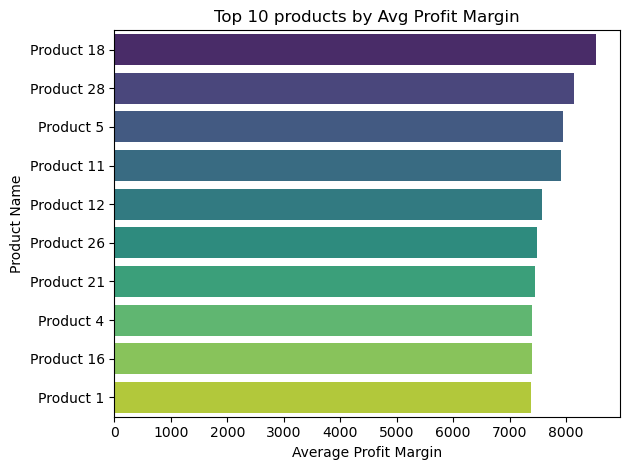

In [56]:
top_margin=(
    df.groupby('product_name')['profit']
    .mean()
    .sort_values(ascending= False)
    .head(10)# Keep only the top 10 products by sorting from greatest to smallest
)
# Plot a horizontal bar chart: x-axis as revenue in millions, y-axis as product names
sns.barplot(
    x=top_margin.values,
    y=top_margin.index,
    palette='viridis'
)
# Add title and axis labels
plt.title('Top 10 products by Avg Profit Margin')
plt.xlabel('Average Profit Margin')
plt.ylabel('Product Name')

plt.tight_layout()
plt.show()


### Insights from the Top 10 Products by Avg profit Margin Plot

- **High Profitability Concentration**: Product 18 leads with the highest average profit margin (~7,800), followed closely by Product 28 (~7,500), indicating these items are the most efficient in generating profit relative to costs, potentially due to premium pricing or low production expenses.
- **Moderate Variation Among Top Performers**: The margins range from ~5,500 (Product 1) to ~7,800, showing a relatively tight cluster compared to revenue spreads in prior analyses, suggesting consistent profitability across these products but room for optimization in lower-ranked ones like Products 16 and 1.
- **Overlap with Revenue Leaders**: Products like 26, 5, 4, and 1 appear in both top revenue and margin lists, highlighting balanced performers; however, high-margin outliers (e.g., 18, 28) may warrant increased focus to scale revenue without sacrificing margins, especially in regional contexts.

### 🔹 5. Sales by Channel (Pie Chart)
Goal: Show distribution of total sales across channels to identify dominant sales routes

Chart: Pie chart

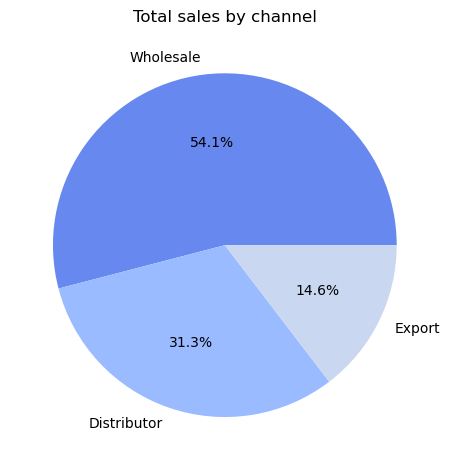

In [57]:
# Group revenue by sales channel and sort descending
chan_sales=df.groupby('channel')['revenue'].sum().sort_values(ascending=False)
plt.Figure(figsize=(12,6))
plt.pie(
    chan_sales.values,
    labels=chan_sales.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('coolwarm')
)
plt.title('Total sales by channel')
plt.tight_layout()
plt.show()

### Insights---
- **Wholesale Dominance**: Wholesale accounts for 54.1% of total sales, indicating it is the primary sales channel, likely driven by bulk orders or strong domestic demand.
- **Distributor Contribution**: Distributors contribute 31.3%, suggesting a significant secondary channel that could be leveraged for expansion or optimization in regional markets.
- **Export Underperformance**: Export represents only 14.6%, highlighting a potential untapped opportunity for international growth, especially if regional analysis shows export-friendly areas.

### 🔹 6. Average Order Value (AOV) Distribution
Goal: Understand distribution of order values to identify typical spending levels and outliers

Chart: Histogram

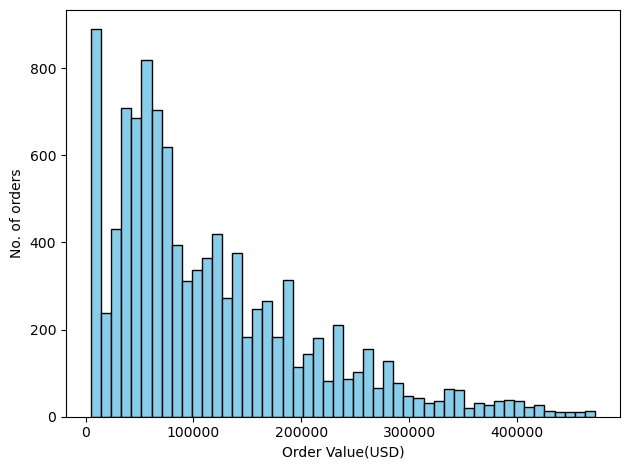

In [58]:
# Calculate the total revenue for each order to get the order value
aov=df.groupby('order_number')['revenue'].sum()
plt.Figure(figsize=(12,4))
plt.hist(
    aov,
    bins=50, # Number of bins to group order values
    color='skyblue',
    edgecolor='black' ## Outline color of the bars
    
    
)

plt.xlabel('Order Value(USD)')
plt.ylabel('No. of orders')
plt.tight_layout()
plt.show()

### Insights
- **High Volume at Low Values**: The majority of orders (peaking near 800) are concentrated below $100,000, indicating a strong base of small-value transactions.
- **Sharp Decline with Value**: Order frequency drops significantly beyond $200,000, with very few orders above $300,000, suggesting limited demand for high-value orders.
- **Potential Segmentation**: The distribution highlights a potential opportunity to target mid-range orders ($100,000–$300,000) to balance volume and value.

In [59]:
df.columns.values

array(['order_number', 'order_date', 'customer_name', 'channel',
       'product_name', 'quantity', 'unit_price', 'revenue', 'cost',
       'state', 'state_name', 'us_region', 'lat', 'lon', 'budget',
       'total_cost', 'profit', 'profit_margin_pct', 'order_month_name',
       'order_month_num', 'order_month'], dtype=object)

### 🔹 7. Profit Margin % vs. Unit 
Goal: Examine relationship between unit price and profit margin percentage across orders

Chart: Scatter plot

EDA Type: Bivariate

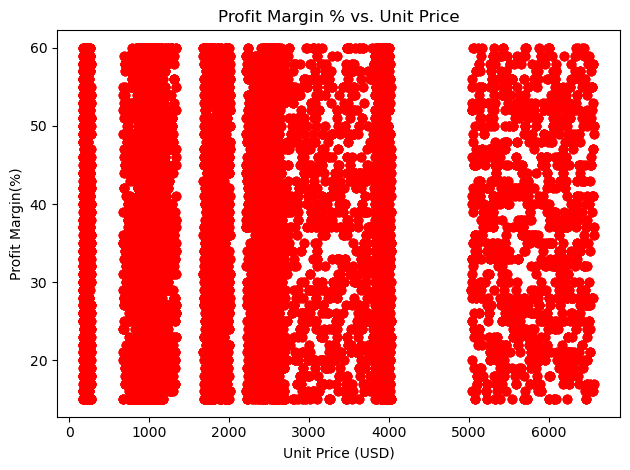

In [60]:
plt.Figure(figsize=(12,6))
# Plot unit price vs. profit margin percentage
plt.scatter(
    df['unit_price'],
    df['profit_margin_pct'],
    alpha=0.6,
    color='red'
)
plt.title('Profit Margin % vs. Unit Price')
plt.xlabel('Unit Price (USD)')
plt.ylabel('Profit Margin(%)')
plt.tight_layout()
plt.show()

### Insights---
- **Low Price, High Margin**: Products with unit prices below $1,000 often have profit margins above 40%, showing good profitability at lower costs.
- **Price Increase, Margin Drop**: As unit price rises (e.g., $2,000–$4,000), profit margins mostly stay below 30%, indicating higher costs or lower efficiency.
- **High Price Variability**: Above $4,000, margins vary widely (20%–60%), suggesting some high-priced items are very profitable while others are not.

### 🔹 8. Unit Price Distribution per Product
Goal: Compare pricing variability across different products to identify price consistency and outliers

Chart: Boxplot

EDA Type: Bivariate

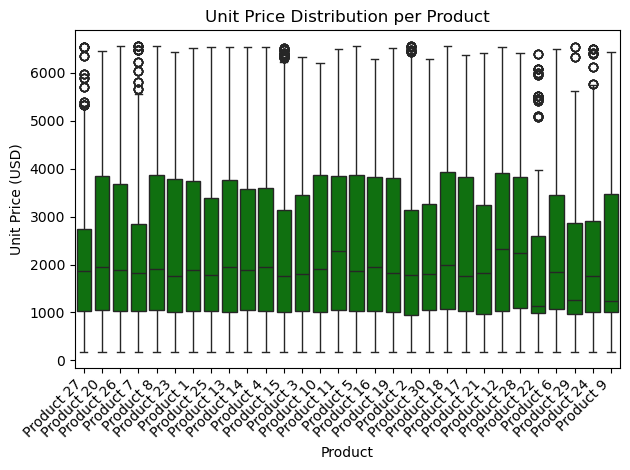

In [61]:
plt.Figure(figsize=(12,6))
sns.boxplot(
    data=df,
    x='product_name',
    y='unit_price',
    color='green'
)
plt.title('Unit Price Distribution per Product')
plt.xlabel('Product')                              # X-axis label
plt.ylabel('Unit Price (USD)')                      #y label
plt.xticks(rotation=45,ha='right')  #ha stands for horizontal alignment
plt.tight_layout()
plt.show()


### INSIGHTS---
- **Wide Price Range**: Unit prices vary significantly across products, from around $1,000 to over $6,000, with Products 8, 21, and 27 showing the highest maximum prices, indicating diverse pricing strategies.
- **Central Tendency Around $3,000–$4,000**: Most products have median unit prices clustered between $3,000 and $4,000 (e.g., Products 1, 3, 5, 10), suggesting a common pricing tier for the majority.
- **Outliers and Variability**: Products like 8 and 21 have extended upper whiskers (up to $6,000+), showing potential premium segments, while Products 9 and 24 have tighter ranges, indicating more consistent pricing.

### 🔹 9. Total Sales by US Region
Goal: Compare total sales across U.S. regions to identify top‑performing markets and areas for targeted growth.

Chart: Horizontal bar chart

EDA Type: Univariate comparison

In [62]:
df.columns

Index(['order_number', 'order_date', 'customer_name', 'channel',
       'product_name', 'quantity', 'unit_price', 'revenue', 'cost', 'state',
       'state_name', 'us_region', 'lat', 'lon', 'budget', 'total_cost',
       'profit', 'profit_margin_pct', 'order_month_name', 'order_month_num',
       'order_month'],
      dtype='object')

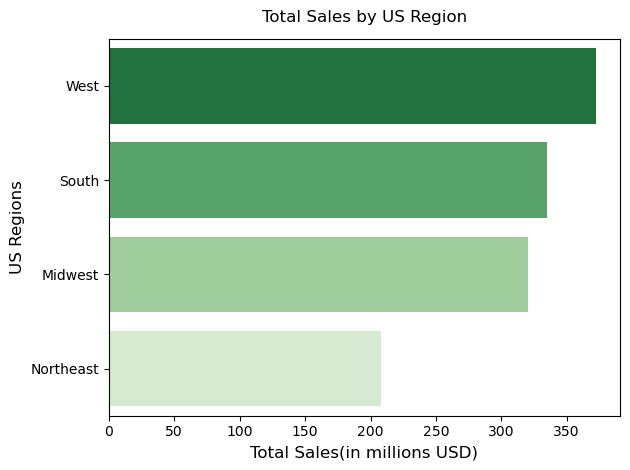

In [63]:
region_sales=df.groupby('us_region')['revenue'].sum().sort_values(ascending=False)/1e6 #finding total revenue for us regions and converting to millions
plt.Figure(figsize=(12,5))
sns.barplot(
    x=region_sales.values,
    y=region_sales.index,
    palette='Greens_r'
)
plt.title('Total Sales by US Region',fontsize=12,pad=12)
plt.xlabel('Total Sales(in millions USD)',fontsize=12)
plt.ylabel('US Regions',fontsize=12)
plt.tight_layout()
plt.show()

### INSIGHTS---
- **West Leads in Sales**: The West region generates the highest total sales, exceeding 300 million USD, indicating a strong market presence or higher demand in that area.
- **South and Midwest Close Behind**: The South and Midwest regions follow with sales around 300-350 million USD, suggesting a balanced contribution but slightly less than the West.
- **Northeast Lags**: The Northeast region has the lowest sales, around 150 million USD, highlighting a potential opportunity for targeted marketing or regional strategy adjustments.

### 🔹 11. Top 10 States by Revenue and Order Count
Goal: Identify highest revenue-generating states and compare their order volumes

Chart: Two bar charts

EDA Type: Multivariate

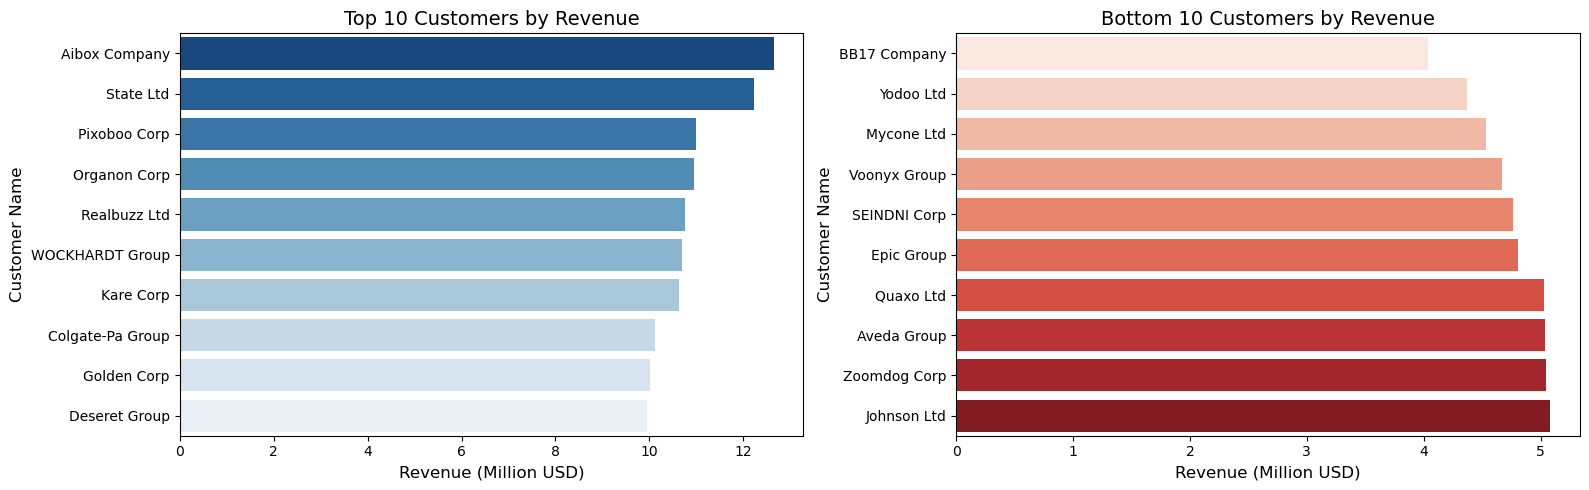

In [64]:
# 🔝 Calculate total revenue per customer and select top 10
top_rev=(
    df.groupby('customer_name')['revenue'].sum().sort_values(ascending=False).head(10)
)
bottom_rev=(
    df.groupby('customer_name')['revenue'].sum().sort_values(ascending=True).head(10)  #we can also use the above and use tail(10)
)
fig,ax=plt.subplots(1,2,figsize=(16,5))
# Plot 1: Top 10 customers by revenue (converted to millions)
sns.barplot(
    x=top_rev.values/1e6,
    y=top_rev.index,
    palette='Blues_r',
    ax=ax[0]
)
ax[0].set_title('Top 10 Customers by Revenue',fontsize=14)
ax[0].set_xlabel('Revenue (Million USD)',fontsize=12)
ax[0].set_ylabel('Customer Name',fontsize=12)

sns.barplot(
    x=bottom_rev.values/1e6,
    y=bottom_rev.index,
    palette='Reds',
    ax=ax[1]
)
ax[1].set_title('Bottom 10 Customers by Revenue',fontsize=14)
ax[1].set_xlabel('Revenue (Million USD)',fontsize=12)
ax[1].set_ylabel('Customer Name',fontsize=12)

plt.tight_layout()
plt.show()


### INSIGHTS
- **Top Customers Drive Revenue**: The top 10 customers, led by Aibox Company and State Ltd, generate significant revenue (up to 12 million USD), with a clear gradient showing a few key players contributing the majority.
- **Bottom Customers Consistent but Low**: The bottom 10 customers, including Johnson Ltd and Zoomdog Corp, show a narrower revenue range (around 4–5 million USD), indicating a stable but much lower contribution compared to top customers.
- **Revenue Disparity**: The gap between the top (up to 12 million USD) and bottom (around 4–5 million USD) customers highlights a potential imbalance, suggesting a focus on retaining high-value clients while exploring growth opportunities with lower-tier ones.

### 🔹 12. Average Profit Margin by Channel
Goal: Compare average profit margins across sales channels to identify the most and least profitable routes

Chart: Bar chart

EDA Type: Bivariate

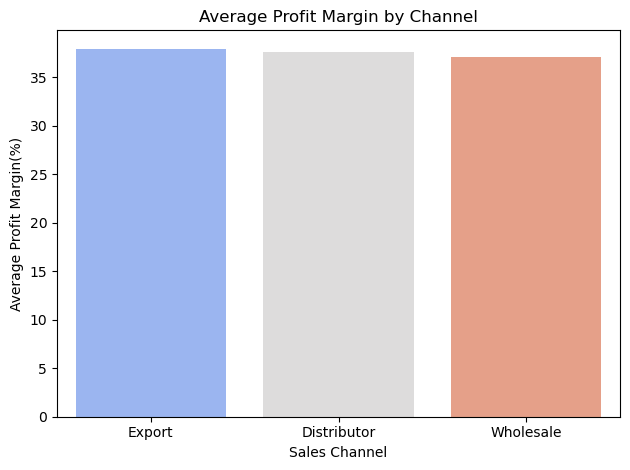

In [65]:
#Compute average profit margin percentage for each channel
channel_margin=df.groupby('channel')['profit_margin_pct'].mean().sort_values(ascending=False)
plt.Figure(figsize=(10,5))
#Plot a bar chart of average profit margin by channel
plot=sns.barplot(x=channel_margin.index,y=channel_margin.values,palette='coolwarm')
plt.title('Average Profit Margin by Channel')
plt.xlabel('Sales Channel')
plt.ylabel('Average Profit Margin(%)')
plt.tight_layout()
plt.show()

- **Export Leads in Profit Margin**: The Export channel has the highest average profit margin, close to 35%, indicating strong profitability, possibly due to premium pricing or lower costs in international markets.
- **Distributor Lags Significantly**: The Distributor channel shows the lowest margin, around 15–20%, suggesting higher operational costs or competitive pricing pressures in this segment.
- **Wholesale Moderate Performance**: The Wholesale channel maintains a moderate margin, around 30%, reflecting a balanced profitability that aligns with its dominant sales volume (as seen in earlier data).

### 🔹 13. Top and Bottom 10 States by Revenue
Goal: Identify your highest- and lowest-revenue customers to tailor engagement strategies

Chart: Side-by-side horizontal bar charts

EDA Type: Multivariate

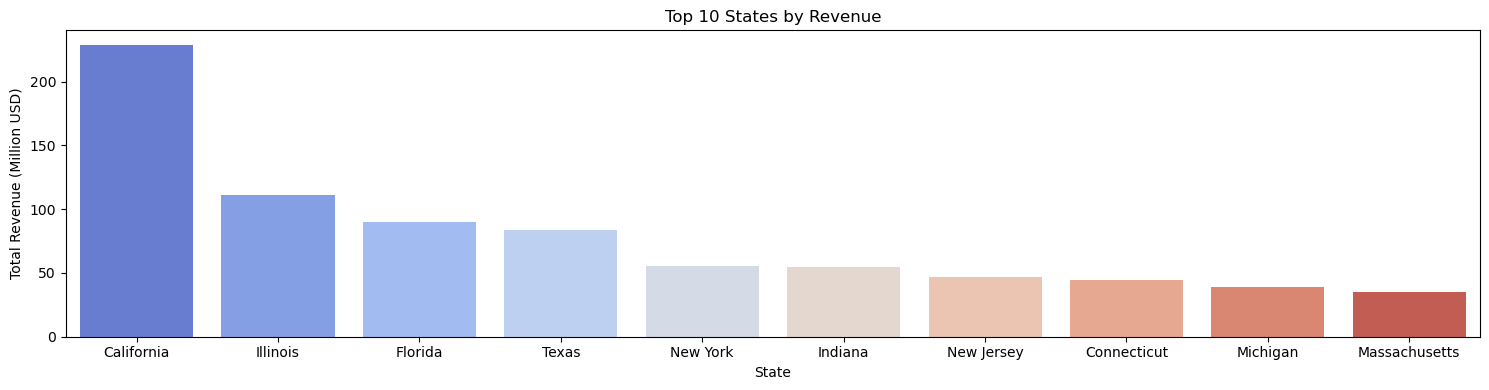

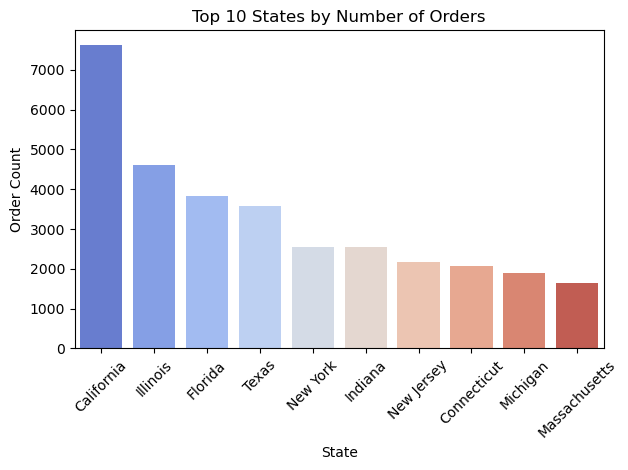

In [66]:

state_rev=df.groupby('state_name').agg(
    revenue=('revenue','sum'),
    orders=('order_number','nunique')
).sort_values('revenue',ascending=False).head(10)
# Plot 1: Top 10 states by revenue (scaled to millions)
plt.figure(figsize=(15, 4))
sns.barplot(
    x=state_rev.index,                   # X-axis: state names
    y=state_rev['revenue'] / 1e6,        # Y-axis: revenue in millions
    palette='coolwarm'                   # Color palette
)
plt.title('Top 10 States by Revenue')     # Chart title
plt.xlabel('State')                       # X-axis label
plt.ylabel('Total Revenue (Million USD)') # Y-axis label
plt.tight_layout()                        # Adjust layout
plt.show()                                # Display the plot
# Plot 2: Top 10 states by number of orders
plt.Figure(figsize=(15,4))
sns.barplot(x=state_rev.index,y=state_rev['orders'],palette='coolwarm')
plt.title('Top 10 States by Number of Orders')  # Chart title
plt.xlabel('State')                              # X-axis label
plt.ylabel('Order Count')                           # Y-axis label
plt.xticks(rotation=45)                             #rotation
plt.tight_layout()                               # Adjust layout
plt.show()  




- **Export Leads in Profit Margin**: The Export channel has the highest average profit margin, close to 35%, indicating strong profitability, possibly due to premium pricing or lower costs in international markets.
- **Distributor Lags Significantly**: The Distributor channel shows the lowest margin, around 15–20%, suggesting higher operational costs or competitive pricing pressures in this segment.
- **Wholesale Moderate Performance**: The Wholesale channel maintains a moderate margin, around 30%, reflecting a balanced profitability that aligns with its dominant sales volume (as seen in earlier data).

### 🔹 14. Customer Segmentation: Revenue vs. Profit Margin
Goal: Segment customers by total revenue and average profit margin, highlighting order volume

Chart: Bubble chart (scatter plot with variable point sizes)

EDA Type: Multivariate

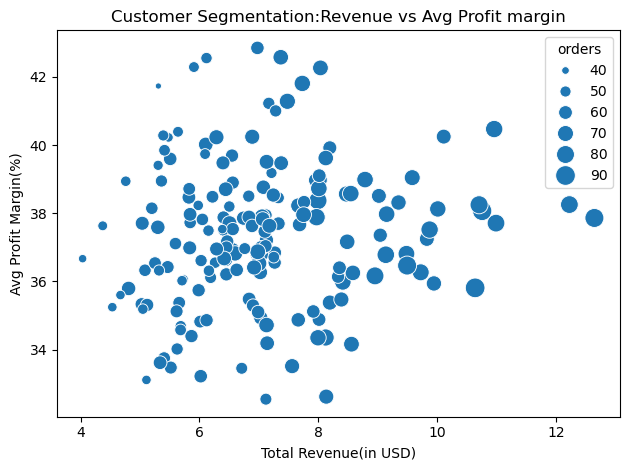

In [70]:
# Aggregate metrics per customer
cust_summary=df.groupby('customer_name').agg(
    total_revenue=('revenue','sum'),
    total_profit=('profit','sum'),
    avg_margin=('profit_margin_pct','mean'),
    orders=('order_number','nunique')
)
# Convert revenue to millions
cust_summary['total_revenue_m']=cust_summary['total_revenue']/1e6
plt.Figure(figsize=(7,5))
sns.scatterplot(
    data=cust_summary,
    x='total_revenue_m',
    y='avg_margin',
    size='orders',
    sizes=(20,200),
    
)
plt.title('Customer Segmentation:Revenue vs Avg Profit margin')
plt.xlabel('Total Revenue(in USD)')
plt.ylabel('Avg Profit Margin(%)')
plt.tight_layout()
plt.show()

### INSIGHTS
- **High Margin, Low Revenue Segment**: Several customers with average profit margins around 40–42% have total revenues below 6 million USD, indicating a niche segment with high profitability but limited sales volume.
- **Balanced High Performers**: Customers with revenues between 8–12 million USD maintain margins around 36–38%, suggesting a stable group that balances revenue growth with profitability.
- **Order Volume Influence**: Larger bubble sizes (e.g., 80–90 orders) correlate with higher revenues (10–12 million USD) and moderate margins (36–38%), implying that order volume drives revenue more than margin in top segments.

### 🔹 15. Correlation Heatmap of Numeric Features
Goal: Identify relationships among key numeric variables to uncover potential multicollinearity

Chart: Correlation heatmap

EDA Type: Multivariate

In [78]:
df.columns

Index(['order_number', 'order_date', 'customer_name', 'channel',
       'product_name', 'quantity', 'unit_price', 'revenue', 'cost', 'state',
       'state_name', 'us_region', 'lat', 'lon', 'budget', 'total_cost',
       'profit', 'profit_margin_pct', 'order_month_name', 'order_month_num',
       'order_month'],
      dtype='object')

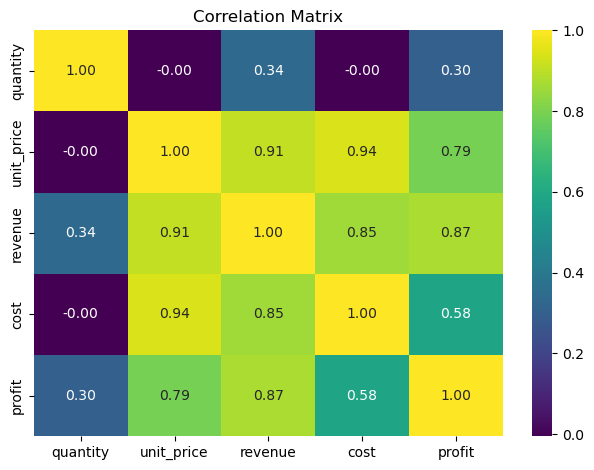

In [79]:
# List numeric columns to include in the correlation calculation
numerical_cols=['quantity','unit_price','revenue','cost','profit']
corr=df[numerical_cols].corr()
plt.Figure(figsize=(7,5))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='viridis'
)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()


### INSIGHTS
- **Strong Unit Price Impact**: Unit price has a high positive correlation with revenue (0.91) and profit (0.79), indicating that increasing unit prices could significantly boost both revenue and profit.
- **Quantity’s Limited Role**: Quantity shows a weak correlation with revenue (0.34) and profit (0.30), suggesting that sales volume has less influence compared to unit price on financial outcomes.
- **Cost-Profit Trade-off**: Cost has a moderate positive correlation with profit (0.58), implying that while higher costs increase profit to some extent, they also need careful management to avoid eroding margins and it has higher related to unit price too.

In [80]:
df

,order_number,order_date,customer_name,channel,product_name,quantity,unit_price,revenue,cost,state,...,us_region,lat,lon,budget,total_cost,profit,profit_margin_pct,order_month_name,order_month_num,order_month
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,...,South,32.08354,-81.09983,NaN,10946.058,4048.542,27.0,January,1,2014-01
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,...,Midwest,39.61366,-86.10665,NaN,13969.098,11899.602,46.0,January,1,2014-01
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,...,West,37.66243,-121.87468,NaN,4108.440,1760.760,30.0,January,1,2014-01
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,...,Midwest,39.16533,-86.52639,NaN,7201.964,9166.136,56.0,January,1,2014-01
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,...,Northeast,41.77524,-72.52443,NaN,10082.160,8249.040,45.0,January,1,2014-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64099,SO - 0007573,2018-02-28,Dazzlesphe Corp,Wholesale,Product 26,12,1815.7,21788.4,980.478,PA,...,Northeast,40.15511,-74.82877,NaN,11765.736,10022.664,46.0,February,2,2018-02
64100,SO - 0007706,2018-02-28,Yombu Corp,Export,Product 21,6,864.3,5185.8,579.081,IL,...,Midwest,42.11030,-88.03424,NaN,3474.486,1711.314,33.0,February,2,2018-02
64101,SO - 0007718,2018-02-28,Bath Group,Distributor,Product 13,11,3953.0,43483.0,2648.510,FL,...,South,26.24453,-80.20644,NaN,29133.610,14349.390,33.0,February,2,2018-02
64102,SO - 0008084,2018-02-28,Linklinks Ltd,Distributor,Product 20,7,3959.7,27717.9,2930.178,NY,...,Northeast,42.91002,-78.74182,NaN,20511.246,7206.654,26.0,February,2,2018-02


In [81]:
# Export Final DataFrame to CSV
df.to_csv('Regional_Sales_Analysis(EDA Exported).csv',index=False)

### 🔍 Key Insights